**SHAP (SHapley Additive exPlanations)** is a game-theoretic framework that explains individual predictions of machine learning models by calculating the fair marginal contribution of each feature to the final prediction.

Introduced by Scott Lundberg and Su-In Lee in 2017, SHAP connects optimal credit allocation from cooperative game theory to local explanations in machine learning.

---

### The Intuition: Cooperative Game Theory

SHAP models a machine learning prediction as a cooperative game:

* **Players:** The feature values of a single data instance (e.g., $Age = 35$, $Income = \$75,000$, $Credit Score = 720$).
* **Payout:** The difference between the model's prediction for this specific instance, $f(x)$, and the average prediction across the entire training dataset, $\mathbb{E}[f(X)]$.
* **Goal:** Fairly divide the payout among the features based on how much each feature contributed to shifting the output away from the baseline average.

---

### Mathematical Definition

The Shapley value $\phi_i(x)$ for feature $i$ on data point $x$ is defined as:

$$\phi_i(x) = \sum_{S \subseteq F \setminus \{i\}} \frac{\vert{}S\vert{}! (\vert{}F\vert{} - \vert{}S\vert{} - 1)!}{\vert{}F\vert{}!} \left[ f_x(S \cup \{i\}) - f_x(S) \right]$$

Where:

* $F$ is the total set of input features.
* $S$ is a subset of features that excludes feature $i$.
* $f_x(S)$ is the model's expected prediction conditioned only on the features in subset $S$.
* $f_x(S \cup \{i\}) - f_x(S)$ is the **marginal contribution** of feature $i$ when added to subset $S$.
* $\frac{\vert{}S\vert{}! (\vert{}F\vert{} - \vert{}S\vert{} - 1)!}{\vert{}F\vert{}!}$ is a combinatorial weight representing the probability of feature $i$ joining coalition $S$ across all possible feature ordering permutations.

---

### The Four Theoretical Guarantees (Axioms)

SHAP is widely considered the gold standard for feature attribution because it uniquely satisfies four mathematical properties:

| Axiom | Meaning | Practical Impact |
| --- | --- | --- |
| **Efficiency (Local Accuracy)** | $\sum_{i=1}^{\vert{}F\vert{}} \phi_i(x) = f(x) - \mathbb{E}[f(X)]$ | The sum of all feature SHAP values equals the exact distance from the dataset average prediction to the target prediction. |
| **Symmetry** | If $f_x(S \cup \{i\}) = f_x(S \cup \{j\})$ for all $S$, then $\phi_i = \phi_j$. | Two features that contribute identically to all subsets receive identical attribution scores. |
| **Dummy (Null Player)** | If $f_x(S \cup \{i\}) = f_x(S)$ for all $S$, then $\phi_i = 0$. | A feature that never changes the prediction receives a SHAP value of zero. |
| **Additivity** | For an ensemble model $f = g + h$, $\phi_i(f) = \phi_i(g) + \phi_i(h)$. | Feature contributions can be added linearly across trees in a forest or boosting ensemble. |

---

### Core SHAP Implementations

Calculating exact Shapley values requires evaluating $2^{\vert{}F\vert{}}$ feature combinations, which becomes computationally intractable for large feature sets. SHAP provides optimized model-specific estimators:

1. **TreeSHAP:** An exact algorithm designed for decision tree ensembles (XGBoost, LightGBM, CatBoost, Random Forest). It computes Shapley values in $O(TLD^2)$ polynomial time instead of exponential time by tracking recursive tree paths.
2. **KernelSHAP:** A model-agnostic technique that uses weighted linear regression (via a specially designed SHAP kernel) as a local surrogate model to estimate Shapley values for any arbitrary black box.
3. **DeepSHAP / GradientSHAP:** Approximations tailored for deep neural networks, combining Shapley value theory with DeepLIFT and integrated gradients.

---

### Standard Visualizations

* **Waterfall / Force Plot (Local):** Illustrates how individual features push a baseline prediction $\mathbb{E}[f(X)]$ up (positive SHAP values) or down (negative SHAP values) to arrive at $f(x)$.
* **Beeswarm Summary Plot (Global):** Aggregates local SHAP values across all dataset instances. Ranks features by global impact while using color to show whether high or low feature values drive the output up or down.
* **Dependence Plot (Feature Interaction):** Plots a feature's raw values against its SHAP values to reveal non-linear relationships and interactions with secondary features.

---

### Trade-offs & Limitations

* **Computational Cost:** KernelSHAP can be extremely slow on high-dimensional datasets ($>100$ features) or large sample sizes without sub-sampling.
* **Correlated Features:** Standard SHAP marginalization assumes feature independence when evaluating absent features, which can lead to sampling unrealistic feature combinations if features are heavily correlated.

# Credit Risk Assessment & Explanation with SHAP

### **Practical Use Case: Explaining Automated Loan Approval / Default Risk**

Financial institutions use XGBoost models to predict loan default risk. However, regulators and underwriters require clear reasoning for *why* a specific applicant was denied or approved. This notebook trains an XGBoost classifier on applicant financial data and uses SHAP to deliver global model auditability and local individual explanations.

In [1]:
%pip install shap xgboost scikit-learn pandas numpy matplotlib -q

### What this cell does

Installs the libraries used in this notebook. `pandas` and `numpy` support data preparation, `matplotlib` creates charts, `scikit-learn` provides the train/test split and metrics, `xgboost` trains the classifier, and `shap` explains the model.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import shap

# Set random seed for reproducibility
np.random.seed(42)
n_samples = 2000

# Generate realistic customer credit risk features
credit_score = np.random.normal(650, 70, n_samples).clip(300, 850)
annual_income = np.random.exponential(60000, n_samples) + 20000
debt_to_income = np.random.beta(2, 5, n_samples) * 100
loan_amount = np.random.normal(25000, 10000, n_samples).clip(2000, 100000)
late_payments_2yr = np.random.poisson(0.8, n_samples)
employment_years = np.random.exponential(5, n_samples).clip(0, 40)

# Define an underlying risk score with noise
risk_score = (
    -0.03 * credit_score
    -0.00005 * annual_income
    + 0.08 * debt_to_income
    + 0.00008 * loan_amount
    + 0.8 * late_payments_2yr
    - 0.15 * employment_years
    + np.random.normal(0, 1, n_samples)
)

# Binary target: 1 = high default risk (denied), 0 = low risk (approved)
default_risk = (risk_score > np.percentile(risk_score, 70)).astype(int)

df = pd.DataFrame({
    'Credit_Score': credit_score,
    'Annual_Income': annual_income,
    'Debt_to_Income_Ratio': debt_to_income,
    'Loan_Amount': loan_amount,
    'Late_Payments_2Yr': late_payments_2yr,
    'Employment_Years': employment_years,
    'Default_Risk': default_risk
})

df.head()

,Credit_Score,Annual_Income,Debt_to_Income_Ratio,Loan_Amount,Late_Payments_2Yr,Employment_Years,Default_Risk
0,684.769991,51364.428383,36.212615,31927.757697,0,7.695947,0
1,640.321499,24097.362834,75.915142,15569.905960,1,0.596722,1
2,695.338198,45738.199838,8.856190,16621.567040,0,6.440909,0
3,756.612090,27059.354293,33.788482,18095.222884,0,2.436023,0
4,633.609264,119089.142605,56.080133,19034.370704,1,0.381050,0


### What this cell does

Imports the numerical, plotting, machine-learning, and SHAP libraries, then creates a reproducible synthetic dataset of 2,000 loan applicants. The features represent credit score, income, debt burden, loan size, recent late payments, and employment history. A noisy risk formula produces the binary `Default_Risk` label, where `1` indicates a high-risk applicant.

In [3]:
X = df.drop(columns=['Default_Risk'])
y = df['Default_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
test_probabilities = model.predict_proba(X_test)[:, 1]

print(f"Model Training Accuracy: {accuracy_score(y_train, train_predictions):.2%}")
print(f"Model Test Accuracy:     {accuracy_score(y_test, test_predictions):.2%}")
print(f"Model Test ROC AUC:      {roc_auc_score(y_test, test_probabilities):.3f}")

Model Training Accuracy: 95.31%
Model Test Accuracy:     87.75%
Model Test ROC AUC:      0.951


### What this cell does

Separates the predictors from the target, creates stratified training and test sets, and trains an XGBoost binary classifier. It reports accuracy on both splits to show generalization and ROC AUC on the test set to measure how well the model ranks higher-risk applicants.

In [4]:
# TreeSHAP computes exact Shapley values efficiently for tree models.
explainer = shap.TreeExplainer(model)

# Compute explanations for each applicant in the test set.
shap_values = explainer(X_test)

print(f"Base Value (Average Dataset Risk Log-Odds): {explainer.expected_value:.4f}")
print(f"Shape of SHAP values matrix: {shap_values.values.shape}")

Base Value (Average Dataset Risk Log-Odds): -0.8645
Shape of SHAP values matrix: (400, 6)


### What this cell does

Creates a `TreeExplainer` for the trained XGBoost model and calculates one SHAP value for every feature and test applicant. The expected value is the model's baseline output, while each SHAP value measures how one feature moves an applicant away from that baseline.

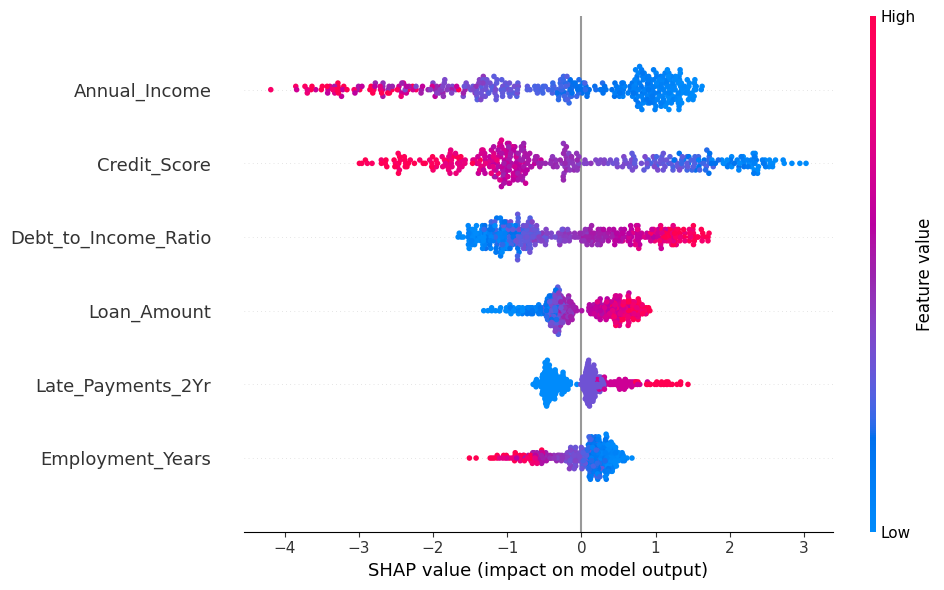

In [5]:
# Global feature-importance and direction summary.
shap.plots.beeswarm(shap_values, max_display=6, show=False)
plt.gcf().set_size_inches(10, 6)
plt.tight_layout()
plt.show()

### What this cell does

Builds a global beeswarm plot from all test applicants. Features are ordered by average impact, the horizontal position shows whether a feature raises or lowers predicted risk, and color indicates whether the original feature value is high or low. Positive SHAP values increase the model's default-risk output.

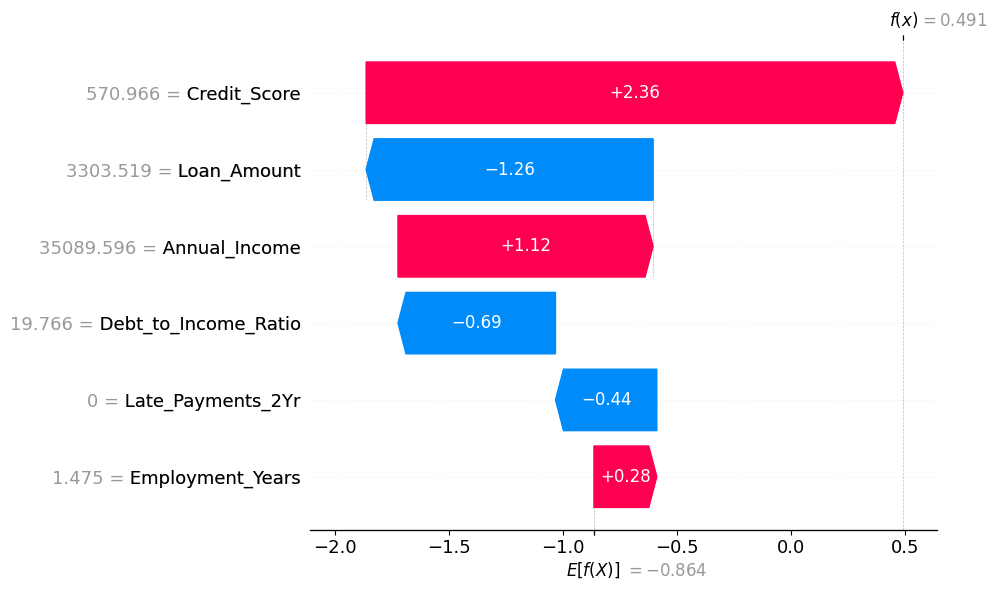

In [6]:
# Select the first applicant predicted as high default risk.
high_risk_indices = np.flatnonzero(test_predictions == 1)
if len(high_risk_indices) == 0:
    raise ValueError("No high-risk applicant was predicted in the test set.")
high_risk_idx = high_risk_indices[0]

# Explain the selected applicant's prediction.
shap.plots.waterfall(shap_values[high_risk_idx], max_display=6, show=False)
plt.gcf().set_size_inches(10, 6)
plt.tight_layout()
plt.show()

### What this cell does

Finds a test applicant that the model classifies as high default risk and creates a waterfall plot for that individual. Red bars show features that increase risk, blue bars show features that reduce risk, and the sequence explains how the baseline becomes this applicant's final model output.

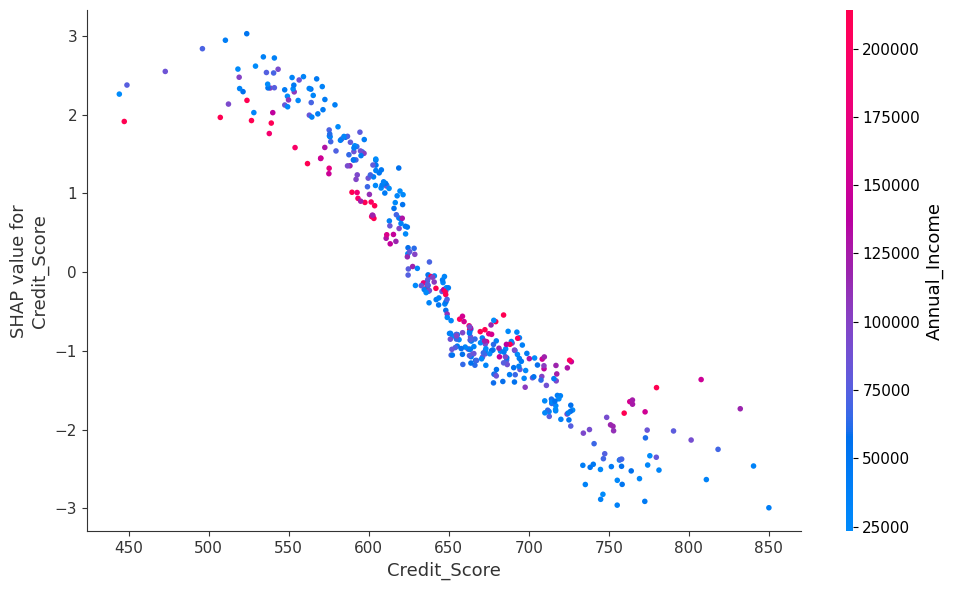

In [7]:
# Show how Credit_Score contributes across applicants.
shap.dependence_plot(
    'Credit_Score',
    shap_values.values,
    X_test,
    interaction_index='Annual_Income',
    show=False
)
plt.gcf().set_size_inches(10, 6)
plt.tight_layout()
plt.show()

### What this cell does

Creates a dependence plot that compares raw `Credit_Score` values with their SHAP contributions. The color scale uses `Annual_Income` to reveal interaction patterns, helping show whether income changes the effect of credit score and whether the relationship is non-linear.